In [1]:
#!pip install pypsa

In [2]:
# Needed imports 
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Path extention
sys.path.append('../src')
sys.path.append('../data')

# Functions import
from Load_Data import load_parquet, construct_dataframe, read_csv
from Plot_Functions import plot_timeseries, compute_market_price_by_country#, create_simple_network
from cost_dict import cost_dict  # as to be a cost_dict.py files

### Loading data

In [138]:
data_dir = Path("../data")
df_dom = pd.read_csv(data_dir / "monthly_domestic_values_2024.csv", sep="\t")
pivot_dom_table = df_dom.pivot_table(index="Month",columns={"Category","Area"}, values="ProvidedValue")
df_load = pd.read_csv(data_dir / "monthly_hourly_load_values_2024.csv", sep="\t")
pivot_load_table = df_load.pivot_table(index="DateUTC",columns="CountryCode", values="Value")
df_pf = pd.read_csv(data_dir / "physical_energy_power_flows_2024.csv", sep=";")
monthly_pf_table = df_pf.pivot_table(index="Month",columns={"FromAreaCode","ToAreaCode"}, values="ProvidedValue")
# print(pivot_load_table['FR'])

In [106]:
def extract_country_dom(pivot_dom_table: pd.DataFrame, country: str) -> pd.DataFrame:
    """
    Extrait les données de production domestique (par catégorie) pour un pays donné.

    Args:
        pivot_dom_table : DataFrame avec colonnes MultiIndex (Category, Area)
        country : code du pays à extraire (ex: "FR", "DE", "ES")
        drop_constant : si True, supprime aussi les colonnes dont toutes les valeurs
                        non-NaN sont identiques (variance nulle).

    Returns:
        DataFrame avec index = Month et colonnes = catégories énergétiques suffixées par _{country}
    """
    if not isinstance(pivot_dom_table.columns, pd.MultiIndex):
        raise ValueError("Le pivot_dom_table doit avoir un MultiIndex (Category, Area).")

    # Filtrer les colonnes correspondant au pays
    # On garde uniquement les colonnes où le niveau 'Area' == country
    # pivot_dom_table.columns est du type MultiIndex[(Category, Area), ...]
    df_country = pivot_dom_table.loc[:, pivot_dom_table.columns.get_level_values(1) == country].copy()

    if df_country.shape[1] == 0:
        # Pas de colonnes pour ce pays
        return pd.DataFrame(index=pivot_dom_table.index)

    # Maintenant renommer à partir des colonnes restantes réelles (évite le décalage)
    # Chaque col est un tuple (Category, Area)
    new_cols = []
    for col in df_country.columns:
        if isinstance(col, tuple) and len(col) >= 2:
            category = col[0]
        else:
            # au cas où ce n'est pas un tuple (defensive)
            category = str(col)
        new_cols.append(f"{category}_{country}")

    df_country.columns = new_cols

    # (Optionnel) tri alphabétique des colonnes pour lisibilité
    df_country = df_country.reindex(sorted(df_country.columns), axis=1)
    
    # Supprimer les colonnes entièrement NaN
    df_country = df_country.dropna(axis=1, how='any')

    return df_country


In [ ]:
def build_hourly_dataframe(countries, pivot_load_table, pivot_pf_table, pivot_dom_table):
    """
    Construit un DataFrame horaire complet pour une liste de pays donnée,
    à partir de tables de production/domestique (mensuelle) et de charge (horaire).
    
    Paramètres :
    ------------
    countries : list[str]
        Liste des pays à inclure (ex: ['FR', 'DE', 'ES'])
    pivot_load_table : pd.DataFrame
        DataFrame des load 
    pivot_pf_table : pd.DataFrame
        DataFrame des power flow 
    pivot_dom_table : pd.DataFrame
        DataFrame des dom 
    
    Retour :
    --------
    pd.DataFrame
        DataFrame horaire complet sur la période commune à toutes les sources
    """
    
    # # Vérifier que les index sont bien datetime
    if not pd.api.types.is_datetime64_any_dtype(df_dom.index):
        df_dom.index = pd.to_datetime(df_dom.index)
    if not pd.api.types.is_datetime64_any_dtype(pivot_load_table.index):
        pivot_load_table.index = pd.to_datetime(pivot_load_table.index, format="%d-%m-%Y %H:%M")
    if pivot_pf_table is not None and not pd.api.types.is_datetime64_any_dtype(df_pf.index):
        df_pf.index = pd.to_datetime(df_pf.index)
    
    # Déterminer la période temporelle totale
    t_min = pivot_load_table.index.min()
    t_max = pivot_load_table.index.max()
    
    # Créer l’index horaire complet
    datetime_index = pd.date_range(start=t_min, end=t_max, freq='h')
    df_final = pd.DataFrame({'datetime': datetime_index})
    df_final.set_index('datetime', inplace=True)
    
    # Boucle sur chaque pays
    for country in countries:
        # Récupérer les colonnes du pays dans chaque table
        col_dom = extract_country_dom(pivot_dom_table, country) if pivot_dom_table is not None else None
        col_load = pivot_load_table[country] if country in pivot_load_table.columns else None
        col_flow = pivot_pf_table[country] if (pivot_pf_table is not None and country in pivot_pf_table.columns) else None
        df_temp = pd.DataFrame({'datetime': datetime_index})
        df_temp.set_index('datetime', inplace=True)
        # Étendre la donnée mensuelle à chaque heure du mois
        if col_dom is not None:
            # col_dom : DataFrame indexé par Month (1..12), colonnes = catégories (ex: 'Wind_FR')
            # On crée une série horaire pour chaque catégorie et on l'ajoute à df_temp
            for col in col_dom.columns:
                monthly_series = col_dom[col].astype(float)  # Series indexée par mois
                hourly = pd.Series(index=datetime_index, dtype=float)
                for month, value in monthly_series.items():
                    # s'assurer que month est un int (1..12)
                    m = int(month)
                    mask = hourly.index.month == m
                    hourly.loc[mask] = value
                # nettoyer le nom de colonne (retirer suffixe _{country} si présent)
                cat = col.replace(f"_{country}", "") if isinstance(col, str) else str(col)
                df_temp[f"{cat}_gen_{country}"] = hourly.values
            # Si tu veux une seule colonne dom agrégée (somme de catégories), décommente :
            # df_temp[f"{country}_dom"] = df_temp[[c for c in df_temp.columns if c.endswith(f'_{country}_dom')]].sum(axis=1)
        else:
             df_final[f"{country}_dom"] = None

        # Ajouter les données horaires
        if col_load is not None:
            df_temp[f'{country}_load'] = col_load
            # df_final[f"{country}_load"] = col_load.reindex(datetime_index, method='nearest')
        else:
            df_final[f"{country}_load"] = None
        
        if pivot_pf_table is not None:
            # Filtrer les colonnes correspondant au pays source
            country_cols = [col for col in pivot_pf_table.columns if col[0] == country]

            if country_cols:
                df_pf_temp = pd.DataFrame({'datetime': datetime_index})

                for (from_area, to_area) in country_cols:
                    col_name = f"From_{from_area}_to_{to_area}"
                    monthly_series = pivot_pf_table[(from_area, to_area)]

                    # Étendre les valeurs mensuelles sur toutes les heures du mois
                    df_pf_hourly = pd.Series(index=datetime_index, dtype=float)
                    for month, value in monthly_series.items():
                        mask = df_pf_hourly.index.month == month
                        df_pf_hourly.loc[mask] = value

                    df_pf_temp[col_name] = df_pf_hourly.values

                # Fusionner avec le df_final
                df_final = pd.merge(df_final, df_pf_temp, on='datetime', how='left')
        df_final = pd.merge(df_final, df_temp, on='datetime', how='left')
        

    return df_final


In [140]:
countries = ["FR",'BE','CH','DE','IT','ES']

df_final = build_hourly_dataframe(countries, pivot_load_table, monthly_pf_table, pivot_dom_table).reset_index(drop=False)
df_final = df_final.rename(columns={'datetime':'DateTime'})
#df_final = df_final.set_index('DateTime')
df_final = df_final.drop(columns = 'index')

print(df_final.head())


             DateTime  From_FR_to_BE  From_FR_to_CH  From_FR_to_DE  \
0 2024-01-01 00:00:00         1017.5        1380.25         1686.0   
1 2024-01-01 01:00:00         1017.5        1380.25         1686.0   
2 2024-01-01 02:00:00         1017.5        1380.25         1686.0   
3 2024-01-01 03:00:00         1017.5        1380.25         1686.0   
4 2024-01-01 04:00:00         1017.5        1380.25         1686.0   

   From_FR_to_ES  From_FR_to_GB  From_FR_to_IT  Biomass_FR_gen  \
0        1518.25        1107.25         1811.5         254.659   
1        1518.25        1107.25         1811.5         254.659   
2        1518.25        1107.25         1811.5         254.659   
3        1518.25        1107.25         1811.5         254.659   
4        1518.25        1107.25         1811.5         254.659   

   Consumption of Hydro Pumped Storage_FR_gen  Fossil Gas_FR_gen  ...  \
0                                     416.211           3527.953  ...   
1                                   

### Visualisation of some dataset variables: 

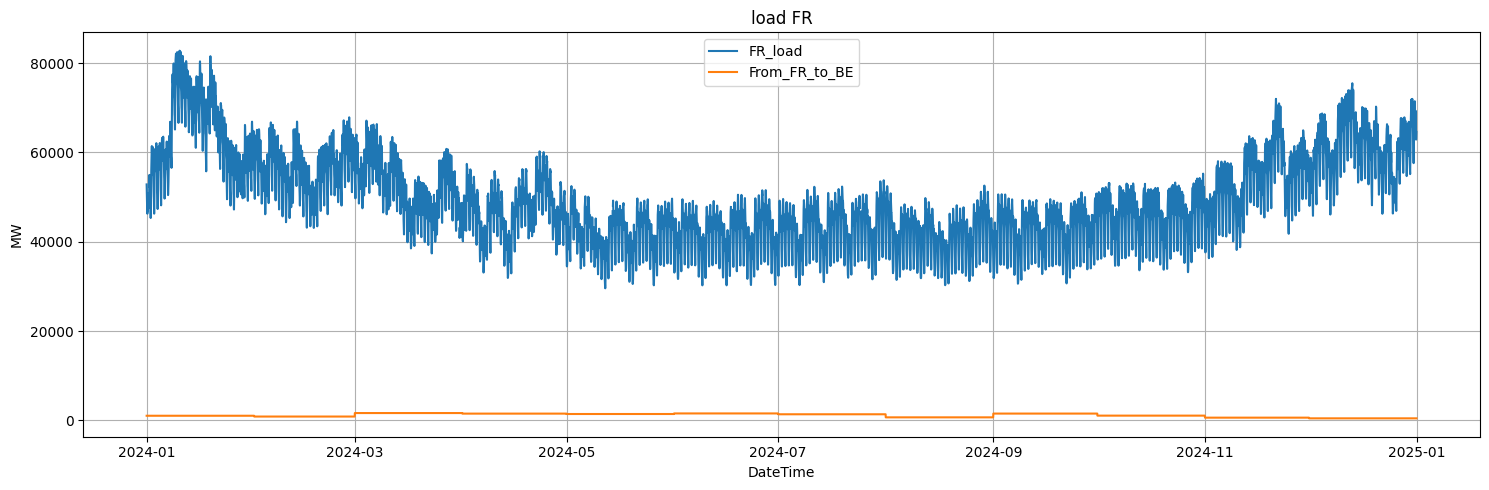

In [ ]:
plot_timeseries(df_final, variables=['FR_load'], title='load FR', ylabel='MW')


### Implementation of a standardized de-normalization function, allowing different functions and estimations to be applied on normalized data

In [ ]:
df_fr = construct_dataframe(df, countries=['FR'], production_name=['Wind', 'Gas', 'Solar', 'Coal', 'Oil', 'Nuclear'])
df_fr.head()

,DateTime,Prod_Wind_FR,Prod_Gas_FR,Prod_Solar_FR,Prod_Oil_FR,Prod_Nuclear_FR,link_FR_ES,Demand_FR,Price_FR
0,2023-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,6334.820759927363,2424.685468751506,397.0615627926673,510.68543635736506,40200.07860418361,-919.5359158508885,49191.8631077668,77.43571469510985
2,2023-01-01 02:00:00,5263.595724808784,2374.1699803342253,787.1368519259374,645.1188728421157,40489.36899205287,-1095.3267467906996,52259.96541543158,70.05441522290648
3,2023-01-01 03:00:00,6432.654408237131,2463.5754243648107,1163.3625167937064,502.2854917250062,41120.44659960073,-1197.4247570167252,55848.2094050262,78.44695963593266
4,2023-01-01 04:00:00,5578.812185894402,2277.6287062947317,1519.1188900729314,654.1161497005553,40933.77899507499,-1133.8667684469833,54561.97778976417,70.82761587514271


### Creation of a cost function, estimating electricity price using the SPOT market, returning the dataframe with the estimated price and the source of the last technology called

In [ ]:
# Vérifie si 'DateTime' est dans l'index
if df.index.name == 'DateTime':
    df = df.reset_index()

# Si 'DateTime' n’est ni dans les colonnes ni dans l’index : erreur
if 'DateTime' not in df.columns:
    raise ValueError("Le DataFrame doit contenir une colonne 'DateTime'.")

# Ajoute la colonne country si besoin
df['country'] = 'FR'

# Appel de la fonction
spot_price_df = compute_market_price_by_country(df, cost_dict)
spot_price_df[['Estimated_Price_FR','marginal_tech_FR']].head()


,Estimated_Price_FR,marginal_tech_FR
0,60,Hydro
1,135,Gas
2,220,Oil
3,220,Oil
4,220,Oil


### Visualization of the difference between real and estimed price

Since this price model is calculated on an hourly basis, the results are not satisfactory. By only considering production, the model does not follow the actual price evolution. Storage and interconnections should also be included, but these values are missing.

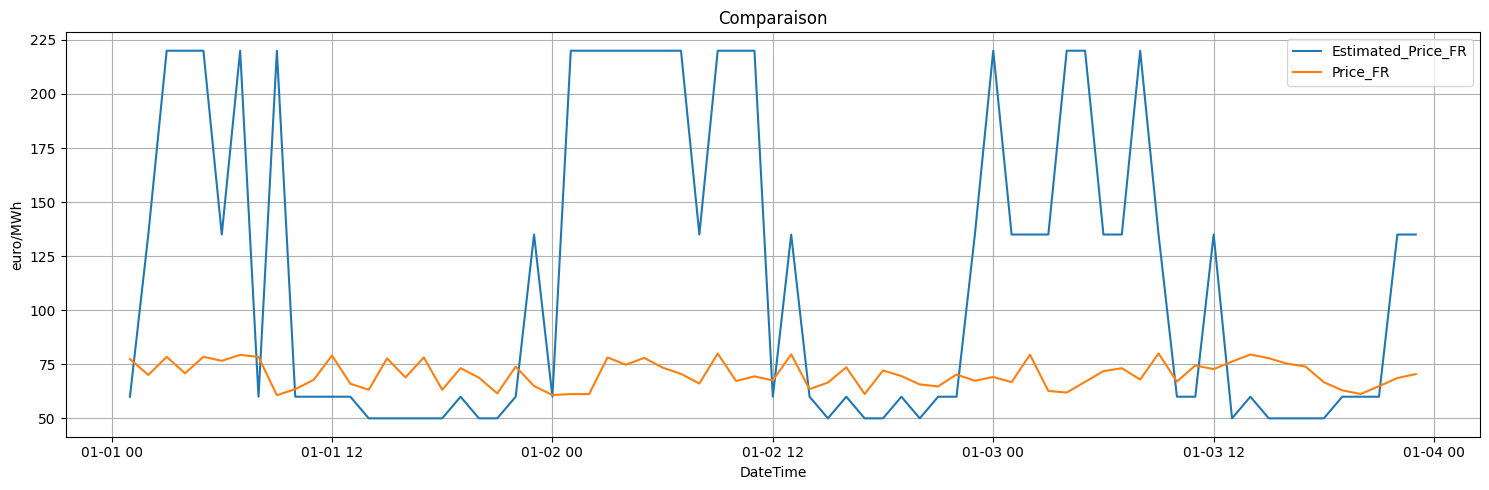

In [ ]:
plot_timeseries(df, variables=['Estimated_Price_FR', 'Price_FR'], title='Comparaison', ylabel='euro/MWh')


Avertissement : colonne Demand_ES manquante.
Avertissement : colonne Demand_DE manquante.


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2b04601b460>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x2b04605c0a0>},
 'flows': {}}

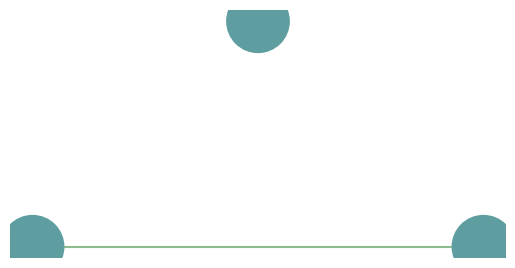

In [ ]:
# Liste de pays présent dans le réseau
countries = ['FR','ES','DE']

# Création du réseau
net = create_simple_network(df,countries, cost_dict)

# Affichage du réseau
net.plot.map()